In [2]:
from matplotlib import pyplot as plt
from scipy import constants
import numpy as np

k = 8.99e9

In [3]:
m1, q1 = constants.m_p, constants.e
m2, q2 = constants.m_p, constants.e

In [4]:
dt = 1e-18
T = 1e-14
MAXN = int(T / dt) + 1

ts = np.zeros(MAXN)
delta_r = np.zeros(MAXN)
r1 = np.zeros(MAXN)
r2 = np.zeros(MAXN)
dr1 = np.zeros(MAXN)
dr2 = np.zeros(MAXN)
ddr1 = np.zeros(MAXN)
ddr2 = np.zeros(MAXN)
ek1 = np.zeros(MAXN)
ek2 = np.zeros(MAXN)
ep = np.zeros(MAXN)

# Initial values
r1[0] = -2e-10 # start left
r2[0] = 2e-10 # start right
dr1[0] = 5e4 # move right
dr2[0] = -5e4 # # move left

# Compute other intial values
delta_r[0] = abs(r2[0] - r1[0])
ek1[0] = 1/2 * m1 * dr1[0] ** 2
ek2[0] = 1/2 * m2 * dr2[0] ** 2
ep[0] = k * (q1 * q2) / delta_r[0]

In [5]:
Estart = 1/2 * m1 * dr1[0] ** 2 + 1/2 * m2 * dr2[0] ** 2 + k * (q1 * q2)/(abs(r2[0] - r1[0]))
vfelles = (m1 * dr1[0] + m2 * dr2[0]) / (m1 + m2)
EKslutt = 1/2 * (m1 + m2) * vfelles ** 2
rmin = (k * q1 * q2) / (Estart - EKslutt)

In [24]:
# Populate the DP table
n = 0
while n < MAXN - 1:
    n += 1
    ts[n] = ts[n-1] + dt

    delta_r[n] = abs(r2[n-1] - r1[n-1])
    F = k * (q1 * q2) / delta_r[n] ** 2

    ddr1[n] = -F / m1 # Particle 1 is pushed left
    ddr2[n] = F / m2 # Particle 2 is pushed right

    dr1[n] = dr1[n-1] + ddr1[n] * dt
    dr2[n] = dr2[n-1] + ddr2[n] * dt

    r1[n] = r1[n-1] + dr1[n] * dt
    r2[n] = r2[n-1] + dr2[n] * dt

    ek1[n] = 1/2 * m1 * dr1[n] ** 2
    ek2[n] = 1/2 * m2 * dr2[n] ** 2
    ep[n] = k * (q1 * q2) / (delta_r[n])

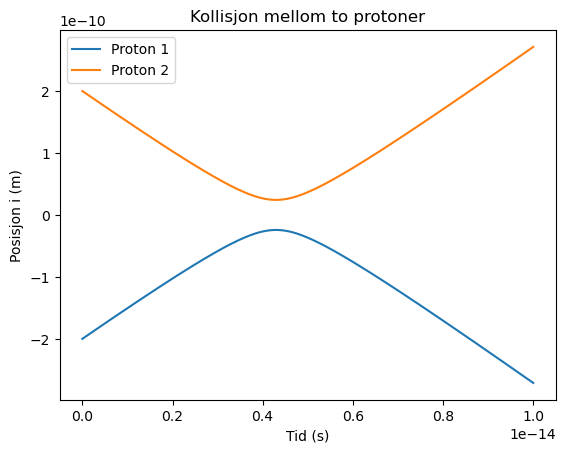

In [16]:
fig, ax = plt.subplots()
ax.plot(ts, r1, label="Proton 1")
ax.plot(ts, r2, label="Proton 2")
ax.set_title("Kollisjon mellom to protoner")
ax.set_xlabel("Tid (s)")
ax.set_ylabel("Posisjon i (m)")
ax.legend()
plt.savefig("assets/proton-collision-position.png", dpi=300)
plt.show()

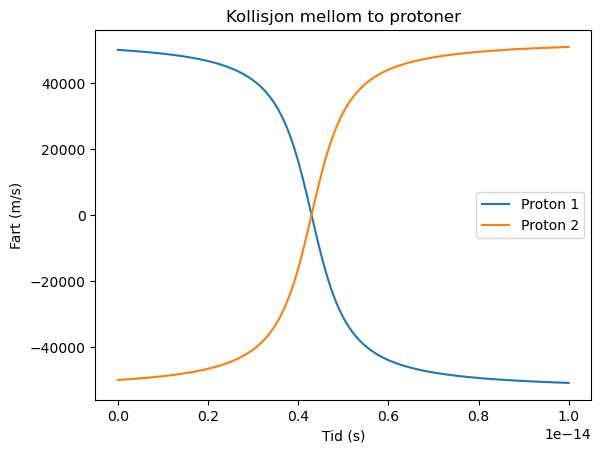

In [18]:
fig, ax = plt.subplots()
ax.plot(ts, dr1, label="Proton 1")
ax.plot(ts, dr2, label="Proton 2")
ax.set_title("Kollisjon mellom to protoner")
ax.set_xlabel("Tid (s)")
ax.set_ylabel("Fart (m/s)")
ax.legend()
plt.savefig("assets/proton-collision-velocity.png", dpi=300)
plt.show()

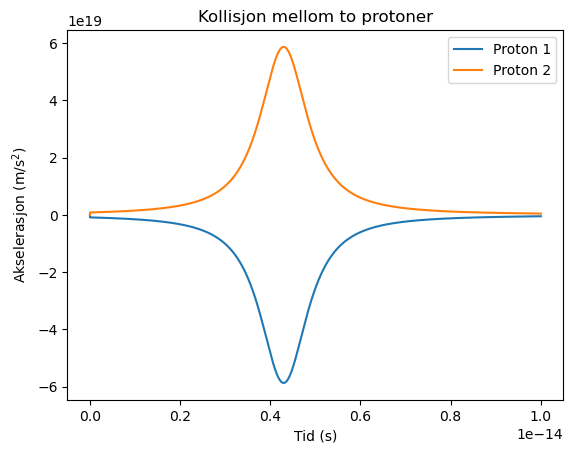

In [22]:
fig, ax = plt.subplots()
ax.plot(ts, ddr1, label="Proton 1")
ax.plot(ts, ddr2, label="Proton 2")
ax.set_title("Kollisjon mellom to protoner")
ax.set_xlabel("Tid (s)")
ax.set_ylabel(r"Akselerasjon ($\mathrm{m/s^2}$)")
ax.legend()
plt.savefig("assets/proton-collision-acceleration.png", dpi=300)
plt.show()

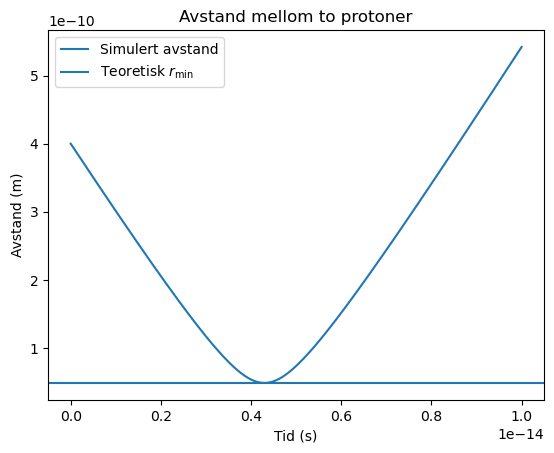

In [23]:
fig, ax = plt.subplots()
ax.plot(ts, delta_r, label="Simulert avstand")
ax.axhline(y=rmin, label=r"Teoretisk $r_{\text{min}}$")
ax.set_title("Avstand mellom to protoner")
ax.set_xlabel("Tid (s)")
ax.set_ylabel("Avstand (m)")
ax.legend()
plt.savefig("assets/proton-collision-distance.png", dpi=300)
plt.show()

In [25]:
rmin

np.float64(4.849669142782682e-11)

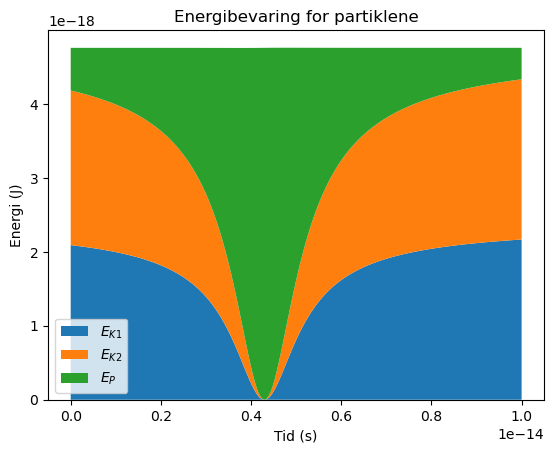

In [27]:
fig, ax = plt.subplots()
labels = ["$E_{K1}$", "$E_{K2}$", "$E_{P}$"]
ax.stackplot(ts, ek1, ek2, ep, labels=labels)
ax.set_title("Energibevaring for partiklene")
ax.set_xlabel("Tid (s)")
ax.set_ylabel("Energi (J)")
ax.legend()
plt.savefig("assets/proton-collision-energy.png", dpi=300)
plt.show()